# Real Estate Data Analysis

In this project, I will analyze the relationship between socioeconomic, demographic, and geographic characteristics and house values in California.

It involves combining **exploratory data analysis** and **machine learning** to investigate the factors associated with **real estate prices** and evaluate whether these characteristics can be used to **predict house values**.

------

I will use the following the pipeline below:

1. **Understand the dataset and its variables.**
2. **Explore the data and identify relevant patterns and relationships.**
3. **Prepare the data for machine learning.**
4. **Split the data into training and testing sets.**
5. **Establish a baseline for model evaluation.**
6. **Train and compare machine learning models.**
7. **Evaluate the best-performing model and interpret its results.**
8. **Discuss the findings and limitations.**

------

In **this notebook**, I will focus on the **first stages of the project**,**covering steps 1 and 2 of the pipeline** above. The **main objective** here is to understand the California Housing dataset and explore the relationships between its socioeconomic, demographic, and geographic characteristics, to **uncover insights** that will give us **valuable information about real estate prices**. 

The **exploratory data analysis** will help **identify patterns** that may be relevant for the machine learning stage, which will be developed in the next notebook.

## Importing the libraries

In [2]:
# Data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

The California Housing dataset is loaded using Scikit-learn. It contains information about housing districts in California and will be used throughout the analysis and modelling stages of this project.

In [3]:
from sklearn.datasets import fetch_california_housing

In [4]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Dataset Overview

In [5]:
df.shape

(20640, 9)

The dataset contains **20,640 observations and 9 columns**. The columns represent socioeconomic, demographic, and geographic characteristics, as well as the target variable used to represent median house values.

### Data Dictionary

| Feature | Description |
|---|---|
| `MedInc` | Median income in the district. |
| `HouseAge` | Median age of houses in the district. |
| `AveRooms` | Average number of rooms per household. |
| `AveBedrms` | Average number of bedrooms per household. |
| `Population` | Total population of the district. |
| `AveOccup` | Average number of household members. |
| `Latitude` | Geographic latitude of the district. |
| `Longitude` | Geographic longitude of the district. |
| `MedHouseVal` | Median house value in the district and the target variable. |


------

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


All variables have **numerical data types** and **no missing values** were identified in the dataset.

------

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


The **descriptive statistics** have provided an initial overview of the **distribution and scale** of our variables. The target variable, `MedHouseVal` **(Median House Value)**, will be explored in more detail during our exploratory data analysis.

------

## Exploratory Data Analysis

**Exploratory Data Analysis (EDA)** is an **important initial step** for **understanding a dataset**, **identifying patterns, and detecting potential anomalies**.

In this section, I will focus on the **distribution of house values and the relationships between the available** socioeconomic, demographic, and geographic **features** and the **target variable**.

### Distribution of House Values

First, I will examine how house values are **distributed across the dataset**.

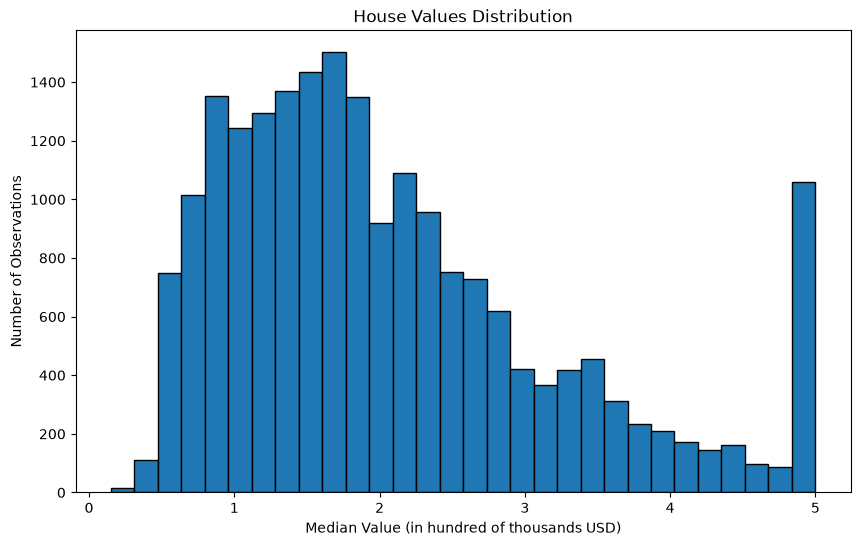

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(df["MedHouseVal"], bins=30, edgecolor="black")

plt.title("House Values Distribution")
plt.xlabel("Median Value (in hundred of thousands USD)")
plt.ylabel("Number of Observations")

plt.show()

Insights:

- Most observations are **concentrated between approximately US$100,000 and US$200,000**. 

- Another notable concentration **appears near the upper limit of approximately US$500,000**.

- **This upper limit may affect both the distribution of the target variable and the model's predictions**.

### Median Income and House Values

Next, I will examine the relationship between median income (`MedInc`) and median house value (`MedHouseVal`).

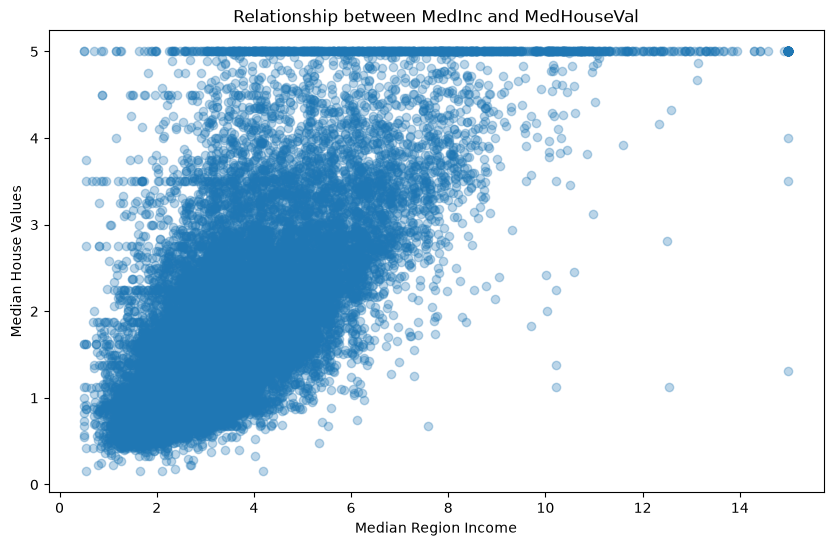

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.3
)

plt.title("Relationship between MedInc and MedHouseVal")
plt.xlabel("Median Region Income")
plt.ylabel("Median House Values")

plt.show()

Insights:
- This suggests a **positive relationship** between **median income** and **house values**. Regions with **higher median incomes** tend to have **higher-valued houses**.
- However, the relationship **isn't perfectly linear**, indicating that **other variables may also influence house values**.
- Another notable concentration **appears near the upper limit of approximately US$500,000**, reinforcing the pattern previously observed in the target distribution.

------

### Correlation Analysis

I will examine the correlation matrix to identify potential linear relationships between the variables, particularly with the target variable, and assess the strength and direction of these relationships.

Correlation values generally range from `-1` to `+1`, where values closer to `+1` indicate a positive linear relationship, values closer to `-1` indicate a negative linear relationship, and values close to `0` indicate little or no linear relationship.

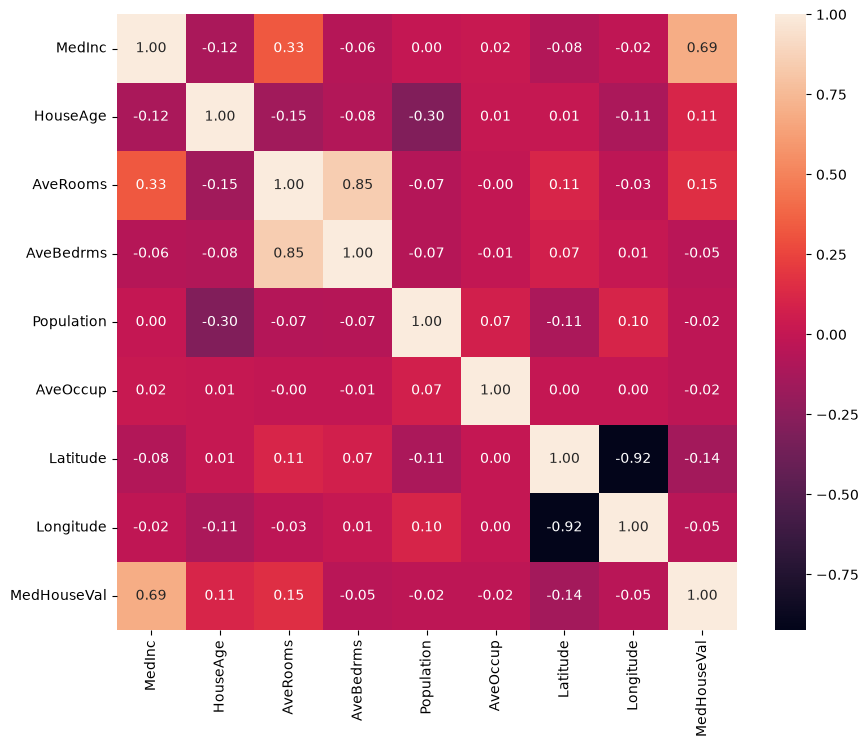

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f"
)

plt.show()

Insights:
- `MedInc` showed the strongest positive correlation with `MedHouseVal`, reinforcing the relationship previously observed during the exploratory analysis.
- `Longitude` and `Latitude` show a strong negative correlation with each other, which is expected because they represent geographic coordinates.
- Individually, the remaining variables show weaker linear relationships with the target variable, suggesting that house values may depend on multiple factors and potentially more complex relationships.

------

### Geographic Distribution

Finally, I will examine the geographic distribution of house values using latitude and longitude.

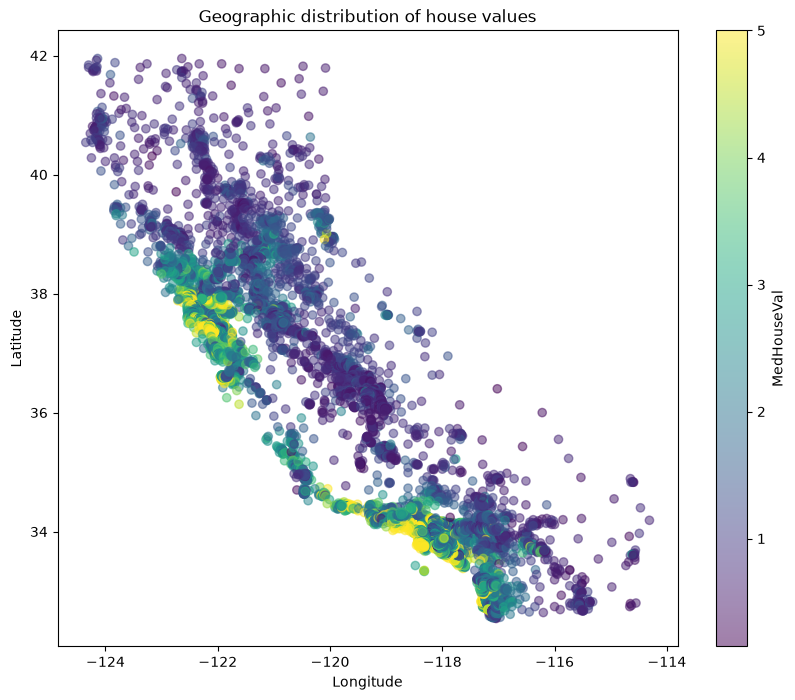

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    alpha=0.5
)

plt.colorbar(label="MedHouseVal")
plt.title("Geographic distribution of house values")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

Insights:
- The shape of the chart resembles California because the dataset includes geographic coordinates from regions within the state. By combining `Longitude` and `Latitude`, it creates a **simplified geographic representation of the data**.
- House values **are not randomly distributed** across the map.
- Some geographic areas show a **higher concentration of more expensive properties**, suggesting that **location contains relevant information for estimating house values**.

------

## EDA Conclusions

The exploratory analysis revealed several important patterns that will guide the machine learning stage of this project.

**Main insights:**

- Most house values are concentrated between approximately **US$100,000 and US$200,000**.
- The **target variable** has a notable concentration near its upper limit of approximately **US$500,000**, which may influence both the data distribution and the model's predictions.
- `MedInc` showed the **strongest relationship** with `MedHouseVal`, suggesting that **median income may be an important feature for predicting house values**.
- **House values are not randomly distributed geographically**, indicating that **location may also provide useful information for prediction**.
- Several variables showed weak individual linear correlations with the **target**, suggesting that **house values may depend on multiple factors and more complex relationships**.

These findings provide a foundation for the next stage of the project, where the available features will be used to train and evaluate machine learning models.